# Motor C: Forecast Dietario con Prophet (2023–2030)

**Aguacate Team · TFM La Dieta de un País**

Este notebook entrena modelos Prophet por país × macrocategoría y genera proyecciones de la composición dietaria hasta 2030.  
El vector dietario proyectado se pasa al LightGBM guardado (`lgb_final.pkl`) para obtener el CO₂ estimado futuro.

**Limitación documentada:** Prophet se entrena con 13 observaciones anuales (2010-2022).  
Los intervalos de confianza al 80% son razonables hasta 2025-2026 pero se amplían considerablemente hacia 2030.  
Interpretar como *escenario tendencial basado en inercia histórica*, no como predicción exacta.

In [1]:
import pandas as pd
import numpy as np
import joblib
import warnings
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
warnings.filterwarnings('ignore')

from prophet import Prophet

SEED = 42
np.random.seed(SEED)

MACROS = [
    'pct_Cereales', 'pct_Tuberculos', 'pct_Azucares',
    'pct_Aceites_Grasas', 'pct_Carnes', 'pct_Lacteos_Huevos', 'pct_Frutas_Verduras'
]
FEATURES_LGB = MACROS + ['log_Food_CPI', 'cluster_id']
HORIZON_YEAR = 2030
HORIZON_PERIODS = HORIZON_YEAR - 2022  # 8 años

MACRO_COLORS = {
    'pct_Cereales':       '#f0a500',
    'pct_Tuberculos':     '#8b4513',
    'pct_Azucares':       '#e84393',
    'pct_Aceites_Grasas': '#ffd700',
    'pct_Carnes':         '#c0392b',
    'pct_Lacteos_Huevos': '#a0a0a0',
    'pct_Frutas_Verduras':'#2ecc71'
}

print('Librerías cargadas')

Librerías cargadas


In [2]:
# ── CARGA DE DATOS Y MODELO ──────────────────────────────────────
df = pd.read_parquet('../processed/03_clusters.parquet')
lgb_model = joblib.load('../processed/lgb_final.pkl')

print(f'Dataset: {df.shape}')
print(f'Países: {df["Area"].nunique()} | Años: {df["Year"].min()}–{df["Year"].max()}')
print(f'Modelo LightGBM cargado: {type(lgb_model).__name__}')

Dataset: (390, 15)
Países: 30 | Años: 2010–2022
Modelo LightGBM cargado: LGBMRegressor


In [3]:
# ── FUNCIÓN PROPHET POR SERIE ────────────────────────────────────
def forecast_serie(series_df, col, country, horizon=HORIZON_PERIODS):
    """
    Entrena Prophet sobre 13 puntos anuales y genera forecast.
    Parámetros conservadores para series cortas:
      - changepoint_prior_scale=0.1 (evita overfitting)
      - seasonality desactivada (datos anuales, no hay ciclos intrayear)
    """
    prophet_df = series_df[['Year', col]].copy()
    prophet_df.columns = ['ds', 'y']
    prophet_df['ds'] = pd.to_datetime(prophet_df['ds'].astype(str) + '-01-01')

    m = Prophet(
        yearly_seasonality=False,
        weekly_seasonality=False,
        daily_seasonality=False,
        seasonality_mode='additive',
        changepoint_prior_scale=0.1,
        interval_width=0.80
    )
    m.fit(prophet_df)

    future = m.make_future_dataframe(periods=horizon, freq='YS')
    forecast = m.predict(future)
    forecast['Area'] = country
    forecast['variable'] = col

    # Clamp proporciones entre 0 y 1
    for c in ['yhat', 'yhat_lower', 'yhat_upper']:
        forecast[c] = forecast[c].clip(0, 1)

    return forecast[['Area', 'variable', 'ds', 'yhat', 'yhat_lower', 'yhat_upper']]

print('Función forecast_serie definida')

Función forecast_serie definida


In [4]:
# ── BUCLE: 30 países × 7 macrocategorías = 210 modelos Prophet ──
records = []
countries = sorted(df['Area'].unique())

for i, country in enumerate(countries):
    sub = df[df['Area'] == country].sort_values('Year')
    for macro in MACROS:
        fc = forecast_serie(sub, macro, country)
        records.append(fc)
    if (i + 1) % 10 == 0:
        print(f'  {i+1}/{len(countries)} países procesados...')

forecast_macros = pd.concat(records, ignore_index=True)
forecast_macros['Year'] = forecast_macros['ds'].dt.year

print(f'\nForecast macros shape: {forecast_macros.shape}')
print(f'Años cubiertos: {forecast_macros["Year"].min()}–{forecast_macros["Year"].max()}')
print(f'Países: {forecast_macros["Area"].nunique()}')

18:30:38 - cmdstanpy - INFO - Chain [1] start processing
18:30:39 - cmdstanpy - INFO - Chain [1] done processing
18:30:39 - cmdstanpy - INFO - Chain [1] start processing
18:30:39 - cmdstanpy - INFO - Chain [1] done processing
18:30:39 - cmdstanpy - INFO - Chain [1] start processing
18:30:39 - cmdstanpy - INFO - Chain [1] done processing
18:30:39 - cmdstanpy - INFO - Chain [1] start processing
18:30:39 - cmdstanpy - INFO - Chain [1] done processing
18:30:39 - cmdstanpy - INFO - Chain [1] start processing
18:30:39 - cmdstanpy - INFO - Chain [1] done processing
18:30:39 - cmdstanpy - INFO - Chain [1] start processing
18:30:39 - cmdstanpy - INFO - Chain [1] done processing
18:30:39 - cmdstanpy - INFO - Chain [1] start processing
18:30:39 - cmdstanpy - INFO - Chain [1] done processing
18:30:39 - cmdstanpy - INFO - Chain [1] start processing
18:30:39 - cmdstanpy - INFO - Chain [1] done processing
18:30:39 - cmdstanpy - INFO - Chain [1] start processing
18:30:39 - cmdstanpy - INFO - Chain [1]

  10/30 países procesados...


18:30:42 - cmdstanpy - INFO - Chain [1] done processing
18:30:42 - cmdstanpy - INFO - Chain [1] start processing
18:30:42 - cmdstanpy - INFO - Chain [1] done processing
18:30:42 - cmdstanpy - INFO - Chain [1] start processing
18:30:42 - cmdstanpy - INFO - Chain [1] done processing
18:30:42 - cmdstanpy - INFO - Chain [1] start processing
18:30:42 - cmdstanpy - INFO - Chain [1] done processing
18:30:42 - cmdstanpy - INFO - Chain [1] start processing
18:30:42 - cmdstanpy - INFO - Chain [1] done processing
18:30:42 - cmdstanpy - INFO - Chain [1] start processing
18:30:43 - cmdstanpy - INFO - Chain [1] done processing
18:30:43 - cmdstanpy - INFO - Chain [1] start processing
18:30:43 - cmdstanpy - INFO - Chain [1] done processing
18:30:43 - cmdstanpy - INFO - Chain [1] start processing
18:30:43 - cmdstanpy - INFO - Chain [1] done processing
18:30:43 - cmdstanpy - INFO - Chain [1] start processing
18:30:43 - cmdstanpy - INFO - Chain [1] done processing
18:30:43 - cmdstanpy - INFO - Chain [1] 

  20/30 países procesados...


18:30:46 - cmdstanpy - INFO - Chain [1] done processing
18:30:46 - cmdstanpy - INFO - Chain [1] start processing
18:30:46 - cmdstanpy - INFO - Chain [1] done processing
18:30:46 - cmdstanpy - INFO - Chain [1] start processing
18:30:46 - cmdstanpy - INFO - Chain [1] done processing
18:30:46 - cmdstanpy - INFO - Chain [1] start processing
18:30:46 - cmdstanpy - INFO - Chain [1] done processing
18:30:46 - cmdstanpy - INFO - Chain [1] start processing
18:30:46 - cmdstanpy - INFO - Chain [1] done processing
18:30:46 - cmdstanpy - INFO - Chain [1] start processing
18:30:46 - cmdstanpy - INFO - Chain [1] done processing
18:30:46 - cmdstanpy - INFO - Chain [1] start processing
18:30:46 - cmdstanpy - INFO - Chain [1] done processing
18:30:46 - cmdstanpy - INFO - Chain [1] start processing
18:30:46 - cmdstanpy - INFO - Chain [1] done processing
18:30:46 - cmdstanpy - INFO - Chain [1] start processing
18:30:46 - cmdstanpy - INFO - Chain [1] done processing
18:30:46 - cmdstanpy - INFO - Chain [1] 

  30/30 países procesados...

Forecast macros shape: (4410, 7)
Años cubiertos: 2010–2030
Países: 30


In [5]:
# ── CONSTRUIR VECTORES DIETARIOS Y PREDECIR CO₂ ─────────────────

# Pivotar: una fila por (país, año), columnas = macrocategorías
pivot = forecast_macros.pivot_table(
    index=['Area', 'Year'],
    columns='variable',
    values='yhat'
).reset_index()
pivot.columns.name = None

# cluster_id: usar el último cluster conocido por país (98.7% estabilidad temporal)
last_cluster = df.groupby('Area')['cluster_id'].last().reset_index()
pivot = pivot.merge(last_cluster, on='Area', how='left')

# log_Food_CPI: último valor conocido como proxy constante
# Limitación documentada: no se modela la evolución del CPI
last_cpi = df.groupby('Area')['Food_CPI'].last().reset_index()
last_cpi['log_Food_CPI'] = np.log(last_cpi['Food_CPI'])
pivot = pivot.merge(last_cpi[['Area', 'log_Food_CPI']], on='Area', how='left')

# Re-normalizar proporciones a que sumen 1 (constraint composicional)
row_sums = pivot[MACROS].sum(axis=1)
pivot[MACROS] = pivot[MACROS].div(row_sums, axis=0)

# Predecir CO₂ con LightGBM
pivot['CO2eq_forecast'] = lgb_model.predict(pivot[FEATURES_LGB]).astype('float32')

print(f'Pivot shape: {pivot.shape}')
print(f'CO2 proyectado — rango: {pivot["CO2eq_forecast"].min():.2f} – {pivot["CO2eq_forecast"].max():.2f} t/cápita')

Pivot shape: (630, 12)
CO2 proyectado — rango: 0.73 – 11.41 t/cápita


In [6]:
# ── GUARDAR PARQUET ──────────────────────────────────────────────
co2_fc = pivot[['Area', 'Year', 'CO2eq_forecast']]
output = forecast_macros.merge(co2_fc, on=['Area', 'Year'], how='left')

output.to_parquet('../processed/05_forecast_dietario.parquet', index=False)
print(f'Guardado: processed/05_forecast_dietario.parquet')
print(f'Shape: {output.shape}')
print(f'Columnas: {output.columns.tolist()}')

Guardado: processed/05_forecast_dietario.parquet
Shape: (4410, 8)
Columnas: ['Area', 'variable', 'ds', 'yhat', 'yhat_lower', 'yhat_upper', 'Year', 'CO2eq_forecast']


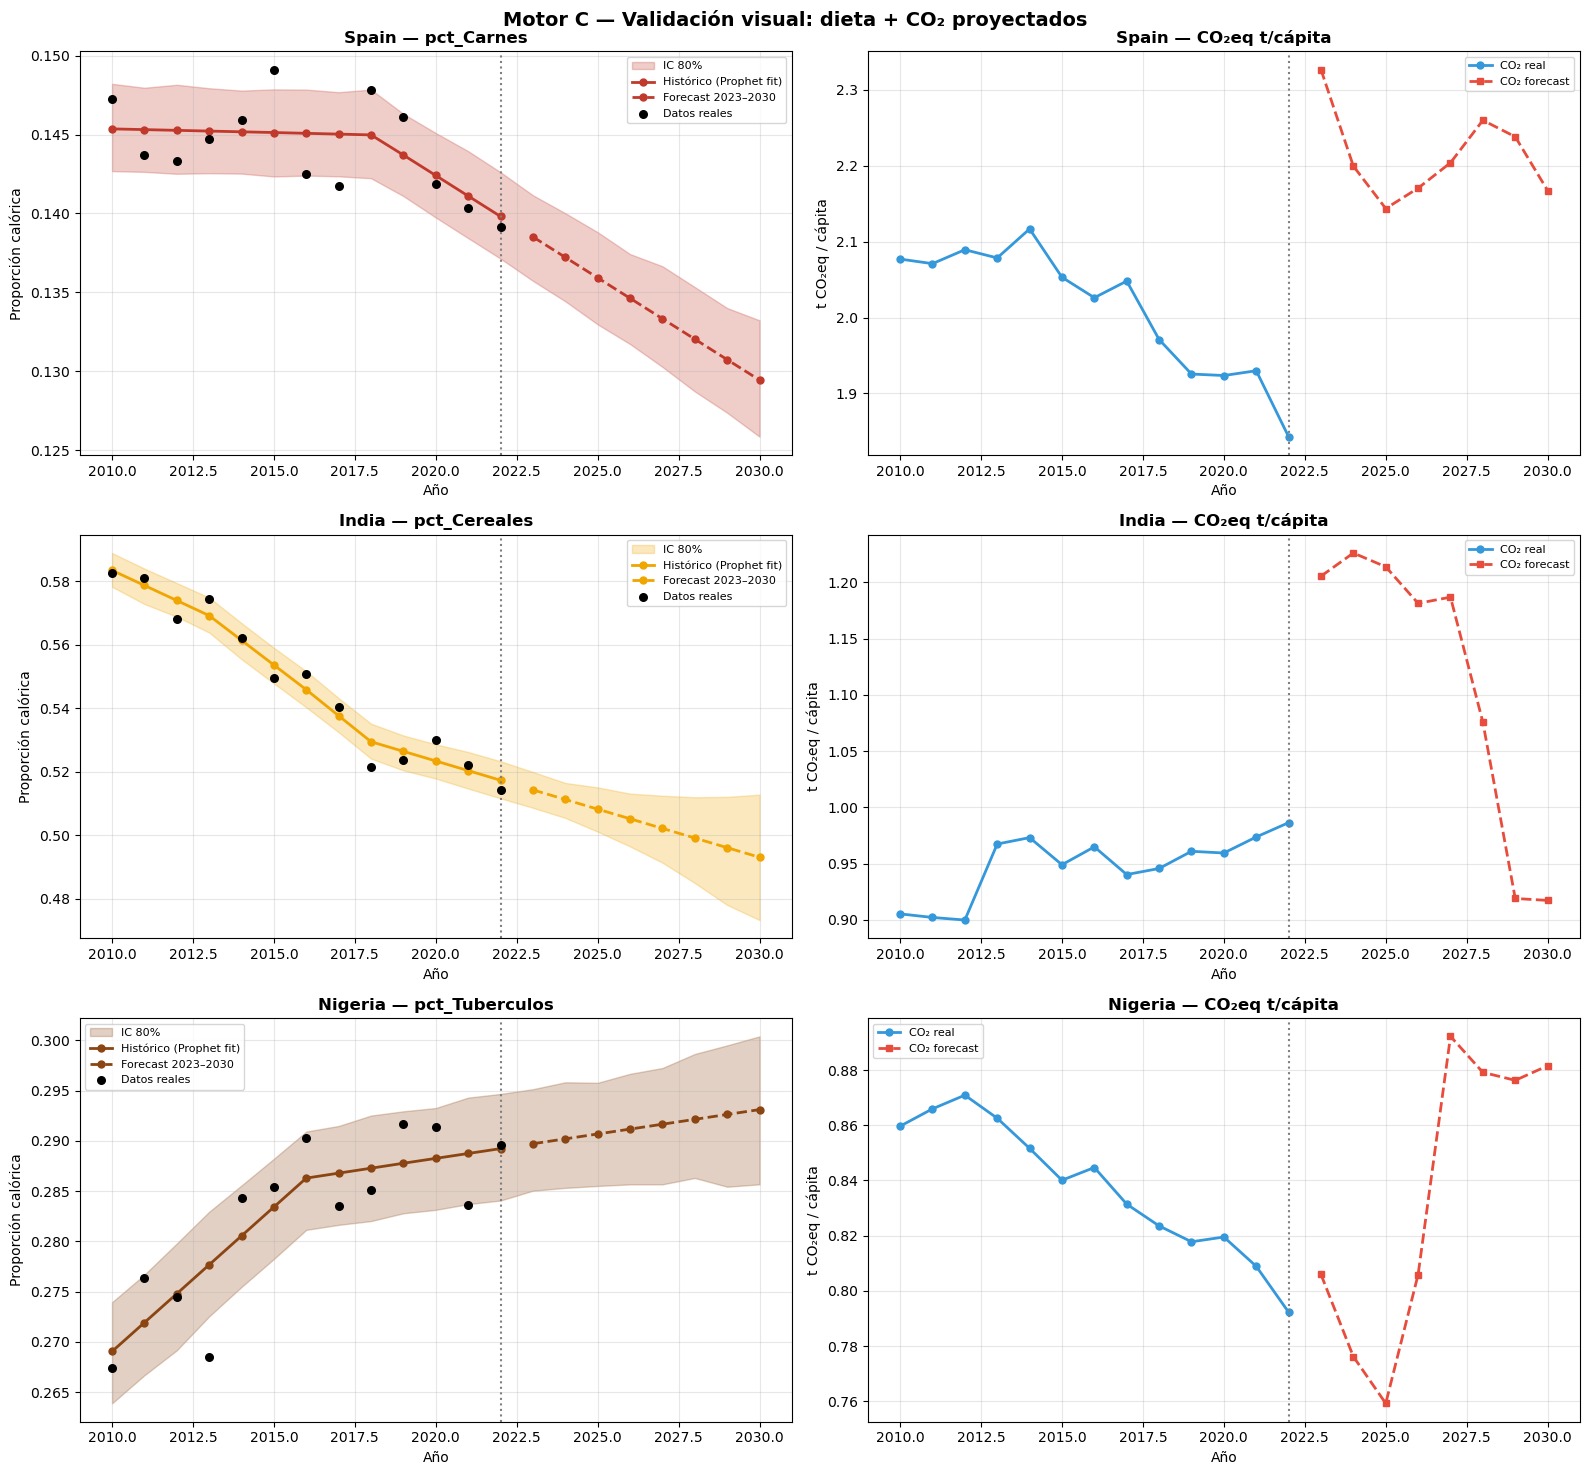

Guardado: processed/05_forecast_validacion.png


In [7]:
# ── VALIDACIÓN VISUAL: 3 países representativos ──────────────────
# Spain (C0-Proteica), India (C2-Cereal), Nigeria (C1-Tuberosa)
VALID_COUNTRIES = ['Spain', 'India', 'Nigeria']

fig, axes = plt.subplots(len(VALID_COUNTRIES), 2, figsize=(16, 5 * len(VALID_COUNTRIES)))

for row, country in enumerate(VALID_COUNTRIES):
    # ── Dieta histórica + forecast para 1 macrocategoría representativa ──
    macro_plot = 'pct_Carnes' if country == 'Spain' else 'pct_Cereales' if country == 'India' else 'pct_Tuberculos'
    fc_country = output[(output['Area'] == country) & (output['variable'] == macro_plot)].sort_values('Year')
    hist_country = df[df['Area'] == country].sort_values('Year')

    ax = axes[row, 0]
    ax.fill_between(
        fc_country['Year'],
        fc_country['yhat_lower'],
        fc_country['yhat_upper'],
        alpha=0.25, color=MACRO_COLORS[macro_plot], label='IC 80%'
    )
    ax.plot(fc_country[fc_country['Year'] <= 2022]['Year'],
            fc_country[fc_country['Year'] <= 2022]['yhat'],
            '-o', color=MACRO_COLORS[macro_plot], lw=2, ms=5, label='Histórico (Prophet fit)')
    ax.plot(fc_country[fc_country['Year'] > 2022]['Year'],
            fc_country[fc_country['Year'] > 2022]['yhat'],
            '--o', color=MACRO_COLORS[macro_plot], lw=2, ms=5, label='Forecast 2023–2030')
    ax.scatter(hist_country['Year'], hist_country[macro_plot],
               color='black', zorder=5, s=30, label='Datos reales')
    ax.axvline(2022, color='gray', linestyle=':', lw=1.5)
    ax.set_title(f'{country} — {macro_plot}', fontweight='bold')
    ax.set_xlabel('Año'); ax.set_ylabel('Proporción calórica')
    ax.legend(fontsize=8); ax.grid(alpha=0.3)

    # ── CO₂ histórico + forecast ──
    co2_hist = hist_country[['Year', 'CO2eq_t_per_capita']]
    co2_proj = pivot[(pivot['Area'] == country)][['Year', 'CO2eq_forecast']]

    ax2 = axes[row, 1]
    ax2.plot(co2_hist['Year'], co2_hist['CO2eq_t_per_capita'],
             '-o', color='#3498db', lw=2, ms=5, label='CO₂ real')
    ax2.plot(co2_proj[co2_proj['Year'] > 2022]['Year'],
             co2_proj[co2_proj['Year'] > 2022]['CO2eq_forecast'],
             '--s', color='#e74c3c', lw=2, ms=5, label='CO₂ forecast')
    ax2.axvline(2022, color='gray', linestyle=':', lw=1.5)
    ax2.set_title(f'{country} — CO₂eq t/cápita', fontweight='bold')
    ax2.set_xlabel('Año'); ax2.set_ylabel('t CO₂eq / cápita')
    ax2.legend(fontsize=8); ax2.grid(alpha=0.3)

plt.suptitle('Motor C — Validación visual: dieta + CO₂ proyectados',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../processed/05_forecast_validacion.png', dpi=150, bbox_inches='tight')
plt.show()
print('Guardado: processed/05_forecast_validacion.png')

In [8]:
# ── TABLA RESUMEN: CO₂ 2022 vs proyectado 2030 ───────────────────
co2_2022 = df[df['Year'] == 2022][['Area', 'CO2eq_t_per_capita']].rename(
    columns={'CO2eq_t_per_capita': 'CO2_2022'})
co2_2030 = pivot[pivot['Year'] == 2030][['Area', 'CO2eq_forecast']].rename(
    columns={'CO2eq_forecast': 'CO2_2030'})

resumen = co2_2022.merge(co2_2030, on='Area')
resumen['Delta_pct'] = ((resumen['CO2_2030'] - resumen['CO2_2022']) / resumen['CO2_2022'] * 100).round(1)
resumen = resumen.sort_values('Delta_pct')

print('CO₂ proyectado 2030 vs observado 2022 (variación %):')
print(resumen.to_string(index=False))

CO₂ proyectado 2030 vs observado 2022 (variación %):
                                                Area  CO2_2022  CO2_2030  Delta_pct
                                              Canada  7.434406  2.385381 -67.900002
                                              Brazil  9.748733  3.195487 -67.199997
                                            Thailand  3.268874  2.287697 -30.000000
                                              Poland  3.586438  2.992711 -16.600000
                                             Romania  2.986566  2.540742 -14.900000
                                            Ethiopia  1.217610  1.073473 -11.800000
                                               India  0.986313  0.917199  -7.000000
                                             Morocco  1.266582  1.181276  -6.700000
                                           Australia  7.687373  7.266189  -5.500000
                                        Saudi Arabia  2.354669  2.312242  -1.800000
                       

## Resumen ejecutivo — Motor C

- **210 modelos Prophet** entrenados (30 países × 7 macrocategorías)
- **Horizonte:** 2023–2030 (8 años de forecast)
- **CO₂ proyectado:** derivado del vector dietario proyectado aplicado al `lgb_final.pkl`
- **Limitación principal:** series de 13 observaciones anuales → intervalos amplios a partir de 2026
- **Output:** `processed/05_forecast_dietario.parquet`
- **Uso en dashboard:** página `05_forecast_dietario.py` del simulador Streamlit